<a href="https://colab.research.google.com/github/maahir-CUsoftwareeng/ECOR1042-Data-Management/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [ ]:
# Import all the necessary libraries here based on course tutorials
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# like tutorial 5
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Leveraging Colab GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


Mount Google Drive and unzip the dataset.

In [ ]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extracting: /content/train/104_PNG.rf.c14671a6a52ae05f9ae2bf1df7e4316e.jpg  
 extracting: /content/train/104_

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ ANSWER. because it dictates how we evaluate and train our model. if a dataset has overwhelmingly more negative samples (No Hydrant) than positive ones, a model can achieve a high overall accuracy by simply guessing "0" for every single image. This makes the model heavily biased towards the majority class and practically useless for detecting the minority class (the hydrants).


Train Labels Head:
                                            filename  Fire Hydrants
0  45-394823_-75-62419684_heading270_jpg.rf.01200...              0
1  53-4733_-113-44139_heading180_jpg.rf.00a4904dd...              0
2     49_jpg.rf.00d3bdf822d633cc6d6fe5ed2c248a59.jpg              1
3  download_jpeg_jpg.rf.00666bac2a7d67fe8f26db4a7...              1
4  45-42126683_-75-64919699_heading270_jpg.rf.02d...              1


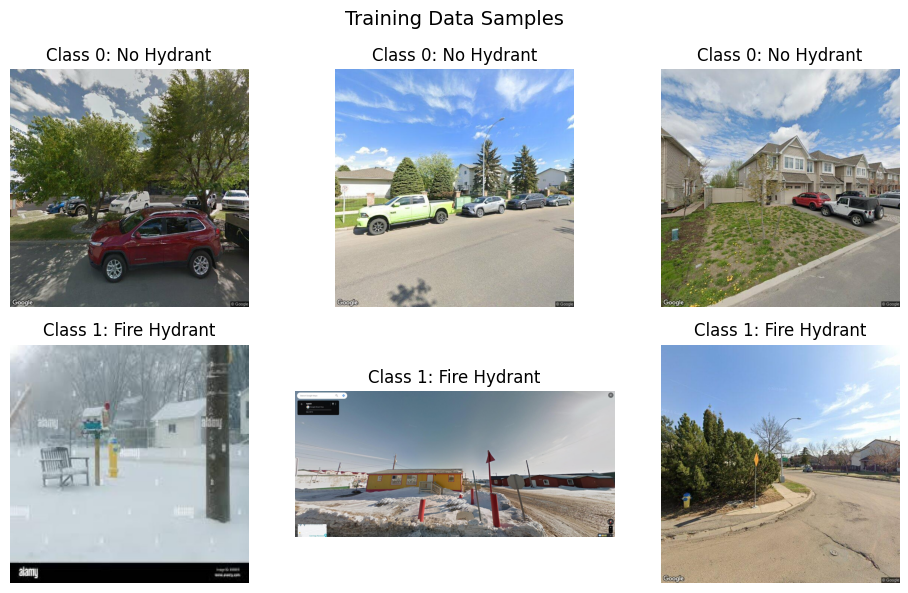

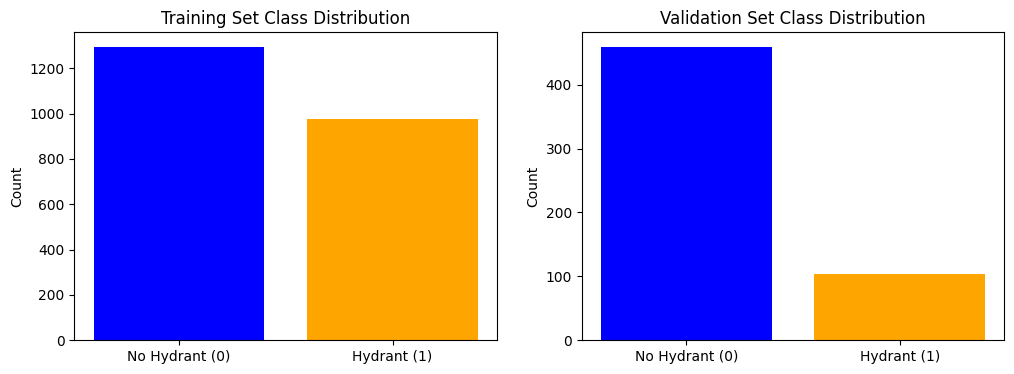

In [ ]:
# load dataset into a pandas DataFrame
print("Train Labels Head:")
print(train_label.head())

# display 3 sample images from each class
def show_samples(df, img_folder, title):
    # Separate the classes
    no_hydrant = df[df.iloc[:, 1] == 0].sample(3, random_state=42)
    hydrant = df[df.iloc[:, 1] == 1].sample(3, random_state=42)

    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    fig.suptitle(title, fontsize=14)

    # platting No Hydrant (Class 0)
    for i, (idx, row) in enumerate(no_hydrant.iterrows()):
        img_path = os.path.join(img_folder, row.iloc[0])
        axes[0, i].imshow(Image.open(img_path))
        axes[0, i].set_title("Class 0: No Hydrant")
        axes[0, i].axis('off')

    # plaooting Fire Hydrant (Class 1)
    for i, (idx, row) in enumerate(hydrant.iterrows()):
        img_path = os.path.join(img_folder, row.iloc[0])
        axes[1, i].imshow(Image.open(img_path))
        axes[1, i].set_title("Class 1: Fire Hydrant")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_label, train_data_path, "Training Data Samples")

# creates class distribution plots of the train and validation data
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(['No Hydrant (0)', 'Hydrant (1)'], train_label.iloc[:, 1].value_counts().sort_index(), color=['blue', 'orange'])
ax[0].set_title('Training Set Class Distribution')
ax[0].set_ylabel('Count')

ax[1].bar(['No Hydrant (0)', 'Hydrant (1)'], valid_label.iloc[:, 1].value_counts().sort_index(), color=['blue', 'orange'])
ax[1].set_title('Validation Set Class Distribution')
ax[1].set_ylabel('Count')
plt.show()

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ ANSWER. one-hot encoding is not necessary since there are only two possible outcomes (0 or 1), so a single output is sufficient

In [ ]:
# custome dataset class similar to Tutorial 6
class FireHydrantDataset(Dataset):
    def __init__(self, csv_data, root_dir, transform=None):
        self.labels = csv_data
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')
        label = float(self.labels.iloc[idx, 1])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# this was discussed in discussion forum for assignment 2 by someone else question, adding normalization to the transforms helps prevent the model from collapsing
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# creates datasets and dataloaders
train_dataset = FireHydrantDataset(train_label, train_data_path, transform=basic_transform)
valid_dataset = FireHydrantDataset(valid_label, valid_data_path, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ ANSWER.
1. add nn.Dropout() before the fully connected layers to randomly "turn off" neurons during training. This forces the network to learn more rather than memorizing the training data.

2) apply random transformations to the training images. this increases the variety in our dataset and makes the model generalize better to new, unseen orientations or lighting conditions.

3) since the dataset is imbalanced, we can pass a pos_weight argument or adjust class weights which penalizes the model when it misses a fire hydrant, forcing it to pay more attention to the minority class rather than just defaulting to "0".

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.flatten = nn.Flatten()

        # 128/2/2 = 32. spatial dims are 32x32. channels = 64
        # 64 * 32 * 32 = 65536
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x.squeeze()

baseline_model = BaselineCNN().to(device)

---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ ANSWER. F1-Score because our dataset has class imbalance, simple Accuracy is a misleading metric (it will look high just by ignoring hydrants). The F1-Score takes the harmonic mean giving a balanced measure so it is is actually capable of detecting the minority class (hydrants) without generating too many false alarms


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ ANSWER. The confusion matrix breaks down the model's specific predictions instead of just giving an overall accuracy score similar to a report card. there are 4 boxes:

true negatives (top left): correctly saw no hydrant.

true positives (bottom right): correctly spotted a hydrant.
false positives (top right): falsely said "Hydrant" at something else

false negatives (bottom left): completely missed an actual hydrant.

i chose F1-Score (approx 0.56), because it evaluates the model based on those bottom two rows and the right column. It gives the AI a high grade only if it successfully maximizes the True Positives while keeping both types of mistakes (the false positives and false negatives) as low as possible.

Training Baseline Model...
Epoch 1/10 - Loss: 0.8298
Epoch 2/10 - Loss: 0.5209
Epoch 3/10 - Loss: 0.4798
Epoch 4/10 - Loss: 0.4318
Epoch 5/10 - Loss: 0.3751
Epoch 6/10 - Loss: 0.3012
Epoch 7/10 - Loss: 0.2197
Epoch 8/10 - Loss: 0.1569
Epoch 9/10 - Loss: 0.0975
Epoch 10/10 - Loss: 0.0497

Baseline Validation Results: Precision: 0.4733, Recall: 0.6827, F1-Score: 0.5591


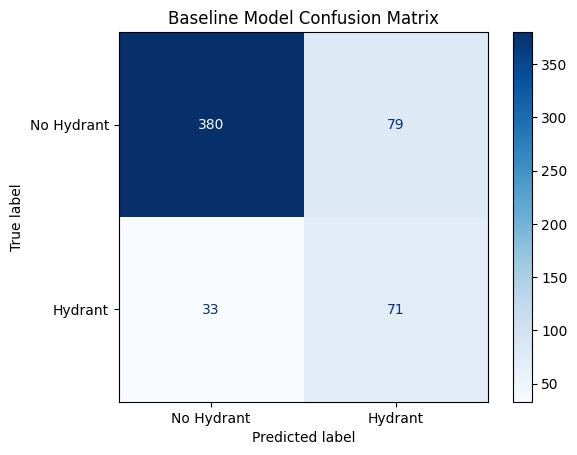

In [ ]:
# loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

epochs = 10
print("Training Baseline Model...")

# training loop
for epoch in range(epochs):
    baseline_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = baseline_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# eval loop
baseline_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = baseline_model(inputs)

        # probabilities to binary predictions
        preds = (outputs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# metrics
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print(f"\nBaseline Validation Results: Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Hydrant", "Hydrant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Baseline Model Confusion Matrix")
plt.show()

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ ANSWER: Out of the 3 improvements tested, weight decay got the highest overall F1-Score (0.5505) and the best Precision (0.5263). By applying L2 regularization (weight decay) directly to the optimizer, we penalized the network for relying on overly large weights. This successfully prevented the model from simply memorizing the training data, leading to better generalization and fewer false positives compared to Dropout and Data Augmentation.

note that data augmentations performed the worst in this specific test (F1: 0.5020). it is generally powerful to prevent overfitting, but training for only 5 epochs is not enough time for the network to learn the much wider, more complex variety of patterns we introduced (like random rotations and flips). given our current metrics, weight decy provides the most stable and balanced performance for immediate deployment

In [ ]:
# helper function to train and test quickly
def evaluate_improvement(model, dataloader_train, name, epochs=5):
    model = model.to(device)
    crit = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=0.001)

    # train
    model.train()
    for epoch in range(epochs):
        for inputs, labels in dataloader_train:
            inputs, labels = inputs.to(device), labels.to(device)
            opt.zero_grad()
            outputs = model(inputs)
            loss = crit(outputs, labels)
            loss.backward()
            opt.step()

    # eval
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for inputs, labels in valid_loader: # validate on original unaugmented valid set
            inputs, labels = inputs.to(device), labels.to(device)
            preds_list.extend((model(inputs) >= 0.5).float().cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    print(f"{name} -> F1: {f1_score(labels_list, preds_list, zero_division=0):.4f} | "
          f"Prec: {precision_score(labels_list, preds_list, zero_division=0):.4f} | "
          f"Rec: {recall_score(labels_list, preds_list, zero_division=0):.4f}")

# improvement 1: dropout
class DropoutCNN(BaselineCNN):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(0.5) # 50% chance to drop neurons
    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x))) # dropout before final layer
        x = self.sigmoid(self.fc2(x))
        return x.squeeze()

# improvement 2: data augmentation
aug_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
aug_train_dataset = FireHydrantDataset(train_label, train_data_path, transform=aug_transform)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=32, shuffle=True)

# improvement 3: weight
# reduce overfitting
baseline_wd = BaselineCNN().to(device)
opt_wd = optim.Adam(baseline_wd.parameters(), lr=0.001, weight_decay=1e-4)

# run evals individually
print("Running separate improvements (5 epochs each to save time)...")
evaluate_improvement(DropoutCNN(), train_loader, "Improvement 1 (Dropout)")
evaluate_improvement(BaselineCNN(), aug_train_loader, "Improvement 2 (Data Augmentation)")

# manual quick train for weight decay
baseline_wd.train()
for epoch in range(5):
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        opt_wd.zero_grad()
        loss = criterion(baseline_wd(inputs), labels)
        loss.backward()
        opt_wd.step()
baseline_wd.eval()
p_list, l_list = [], []
with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs = inputs.to(device)
        p_list.extend((baseline_wd(inputs) >= 0.5).float().cpu().numpy())
        l_list.extend(labels.numpy())
print(f"Improvement 3 (Weight Decay) -> F1: {f1_score(l_list, p_list, zero_division=0):.4f} | Prec: {precision_score(l_list, p_list, zero_division=0):.4f} | Rec: {recall_score(l_list, p_list, zero_division=0):.4f}")

Running separate improvements (5 epochs each to save time)...
Improvement 1 (Dropout) -> F1: 0.5487 | Prec: 0.5082 | Rec: 0.5962
Improvement 2 (Data Augmentation) -> F1: 0.5020 | Prec: 0.4336 | Rec: 0.5962
Improvement 3 (Weight Decay) -> F1: 0.5505 | Prec: 0.5263 | Rec: 0.5769


---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ ANSWER. Yes I tested the model on a picture of an empty road. Even though there is no fire hydrant present, the model confidently flagged it as a hydrant with an 86% probability false positive.

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ ANSWER. There are some patterns:
true positive: the model successfully detected a standard red fire hydrant. Because it perfectly matched the dominant class in the training data

false negative ( Yellow Hydrant): The model missed the yellow fire hydrant. This shows the model over-relies on the color red as a primary feature map.

false positive: The model predicted a hydrant (86% confidence) on an empty street corner. Because many hydrants in the training set are likely located on roads or streets, the model learned to associate the background with the hydrant class maybe


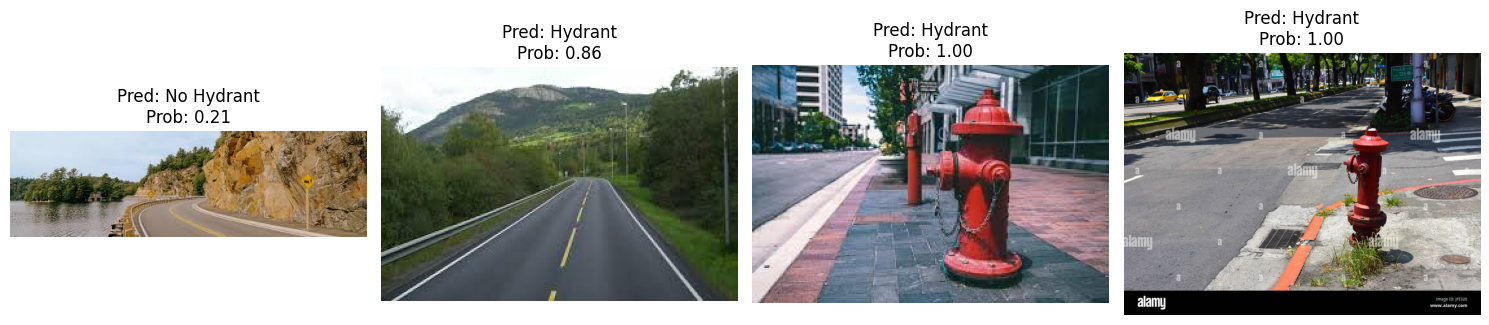

In [ ]:
custom_images_dir = "custom_images"

baseline_model.eval()
fig, axes = plt.subplots(1, len(test_files), figsize=(15, 4))

for i, img_path in enumerate(test_files):
    img_pil = Image.open(img_path).convert('RGB')
    # transform used in training
    img_tensor = basic_transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = baseline_model(img_tensor).item()
        pred_label = "Hydrant" if prob >= 0.5 else "No Hydrant"

    axes[i].imshow(img_pil)
    axes[i].set_title(f"Pred: {pred_label}\nProb: {prob:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ ANSWER. rather than classifying the entire image frame, I'd use an Object Detection architecture (like YOLO or Faster R-CNN) that can draw bounding boxes, since fire hydrants usually only occupy a tiny portion of a image.


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ ANSWER. I mainly relied on the past tutorials to understand but I took some help for syntax for the confusionmatrix syntax and to understand if i got stuck somewhere such as when to use squeeze() and helped me write this print statement quickly

 print(f"Improvement 3 (Weight Decay) -> F1: {f1_score(l_list, p_list, zero_division=0):.4f} | Prec: {precision_score(l_list, p_list, zero_division=0):.4f} | Rec: {recall_score(l_list, p_list, zero_division=0):.4f}")


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

